<a href="https://colab.research.google.com/github/BhavikBuchke/Cisco-Data-science-program/blob/main/Data%20modeling/Poison%20Dart%20Frogs%20Project/poison%20dart%20frogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poison dart frogs

Can you estimate how toxic a poison dart frog is based on its brightness?

Poison dart frogs are small, colorful frogs from Central and South America. They're famous for their toxic skin, which some indigenous people use for blow darts.

Scientists studied the connection between the bright colors and toxicity of the poison dart frog **Dendrobates pumilio**. While they're usually red with blue legs, they can be found in about 15 different colors in Panama.

The file `frog-reflectance.csv` contains the average brightness (from 0 to 1) of 10 frog populations, measured on both the back and belly.

The file `frog-toxicity.csv` provides a `toxicity` score (from 0 to 1) for 48 frogs from the same 10 populations. Toxicity was tested by injecting frog skin extracts into mice and recording how long it took them to fall back asleep. Longer times suggest higher `toxicity`.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'frog-reflectance.csv', 'frog-toxicity.csv', and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving frog-reflectance.csv to frog-reflectance.csv
Saving frog-toxicity.csv to frog-toxicity.csv
Saving linear_model.py to linear_model.py


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('frog-reflectance.csv')
df.head()

,pop_id,back_brightness,belly_brightness
0,AG,0.43,0.46
1,AL,0.64,0.42
2,BCG,1.00,0.95
3,BCO,0.82,1.00
4,CA,0.46,0.51


In [3]:
tox = pd.read_csv('frog-toxicity.csv')
tox.head()

,pop_id,frog_id,toxicity
0,BCO,BC167,0.886925
1,BCO,BC166,0.803917
2,BCO,BC171,0.625008
3,BCO,BC169,0.975847
4,BCO,BC165,0.774033


# Project Ideas

- Build two linear models:
	- Model 1: `toxicity` (x-axis) vs. `back_brightness`

	- Model 2: `toxicity` vs. `belly_brightness`

- To create the models, first calculate the average `toxicity` for each `pop_id`, then merge these values into the main dataframe (`df`).

- Visualize the data by creating scatter plots with best-fit lines for both models.

- Compare the goodness of fit between back and belly brightness and explore possible biological explanations for any differences in correlation.


In [4]:
# Calculate the average toxicity for each pop_id, then merge these values into the main dataframe (df).
avg_tox = tox.groupby('pop_id')['toxicity'].mean().round(2)
df_merg = pd.merge(df, avg_tox, on='pop_id')
df_merg.head()

,pop_id,back_brightness,belly_brightness,toxicity
0,AG,0.43,0.46,0.63
1,AL,0.64,0.42,0.50
2,BCG,1.00,0.95,0.89
3,BCO,0.82,1.00,0.81
4,CA,0.46,0.51,0.36


In [7]:
# Linear Model 1: toxicity vs back_brightness.
x_1 = df_merg['toxicity']
y_1 = df_merg['back_brightness']
x_min = x_1.min()
x_max = x_1.max()
Model_1 = LinearModel()
Model_1.fit(x_1, y_1)
Model_1.print_model_info()

LinearModel():
Slope: 0.5765146783260462
Intercept: 0.3163866333541537
R-squared: 0.6118994372228728


In [8]:
# Linear Model 2: toxicity vs. belly_brightness.
x_2 = df_merg['toxicity']
y_2 = df_merg['belly_brightness']
x_min = x_2.min()
x_max = x_2.max()
Model_2 = LinearModel()
Model_2.fit(x_2, y_2)
Model_2.print_model_info()

LinearModel():
Slope: 0.3465021861336665
Intercept: 0.39449375390381014
R-squared: 0.1842266510999152


In [23]:
def good_look():
  ax = plt.gca()
  ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
  ax.tick_params(axis='both', length=0)
  ax.grid()
  ax.set_xlabel('toxicity')

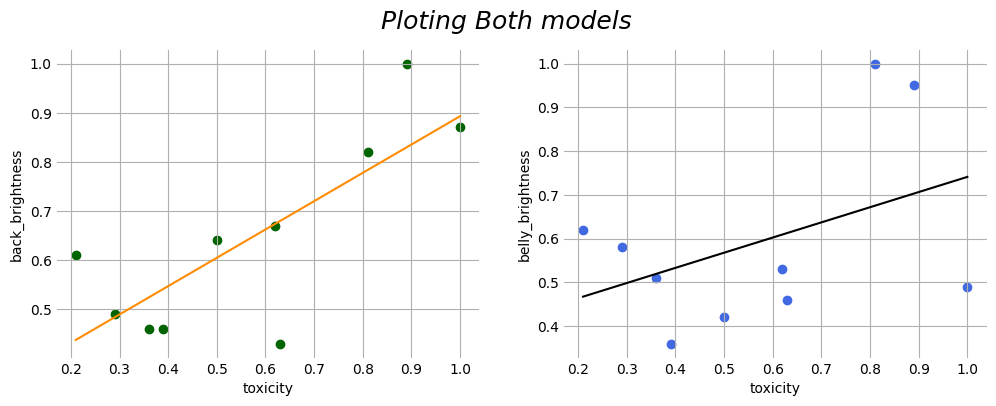

In [30]:
plt.figure(figsize=(12,4))
plt.suptitle('Ploting Both models', fontsize=18, style='italic')

plt.subplot(1,2,1)
plt.scatter(x_1, y_1,color= 'darkgreen')
Model_1.plot_model(x_min, x_max, color= 'darkorange')
plt.ylabel('back_brightness')
good_look()

plt.subplot(1,2,2)
plt.scatter(x_2, y_2, color= 'royalblue')
Model_2.plot_model(x_min, x_max, color= 'black')
plt.ylabel('belly_brightness')
good_look()

### Comparison of R-squared values

- **Model 1 (toxicity vs. back_brightness)**: The R-squared value is approximately **0.612**.
- **Model 2 (toxicity vs. belly_brightness)**: The R-squared value is approximately **0.184**.

Comparing these two values, **Model_1** (back_brightness) has a significantly higher R-squared value than **Model_2** (belly_brightness). This indicates that the **back_brightness** model explains a much larger proportion of the variance in **toxicity** compared to the **belly_brightness** model. Therefore, **back_brightness** shows a stronger correlation with **toxicity**.

## **Biological Explanations**

A possible biological reason for this difference is that the back of a frog is generally more exposed and visible to predators in its natural habitat than its belly. Therefore, bright coloration on the back serves as a more effective aposematic signal (a warning to predators about the frog's toxicity). The stronger correlation suggests that this visible signal on the back is a primary means by which frogs communicate their toxicity to deter potential threats.

### **Data Analysis Key Findings**
*   The linear model predicting toxicity based on **back_brightness** yielded an R-squared value of approximately 0.612.
*   The linear model predicting toxicity based on **belly_brightness** yielded a lower R-squared value of approximately 0.184.
*   **Back_brightness** explains a significantly larger proportion (0.612) of the variance in **toxicity** compared to **belly_brightness** (0.184), indicating a much stronger correlation between **back_brightness** and **toxicity**.

### **Insights**
*   The strong correlation between back brightness and toxicity suggests that back coloration likely serves as a crucial aposematic signal, effectively communicating a frog's toxicity to predators.